# Notebook 08: Feature Selection and Learning-Rate Tuning

This notebook records the strongest point of the holdout-based XGBoost tuning track in the updated series. It combines targeted feature selection with a small learning-rate study before the project later shifts toward stronger validation design.


08_xgboost_test_4: Feature selection + learning rate tuning

1. Load data...
Train shape: (700000, 26)

2. Prepare data...

Create selected engineered features:
 ✓ age_family_history created (importance: 0.3596)
 ✓ age_bmi created (importance: 0.0491)
 ✓ cardio_risk_score created (importance: 0.0111)
 ✓ Cholesterol metrics created

Created a total of 5 new features

3. Feature selection...
Original feature count: 29
Selected feature count: 27
Removed features: age, family_history_diabetes

4. Encode categorical features...
Total encoded feature count: 45
Train set: (560000, 45), Validation set: (140000, 45)

scale_pos_weight: 0.604

Best results from Experiment 07:
- AUC: 0.7251
- Recall class 0: 0.696
- Recall class 1: 0.629

5. Try different learning rates...

▶ Train learning_rate=0.05, n_estimators=600...
 AUC: 0.7247 | Recall class 0: 0.696 | Recall class 1: 0.629 | Mean F1: 0.648

▶ Train learning_rate=0.08, n_estimators=375...
 AUC: 0.7244 | Recall class 0: 0.694 | Recall class 

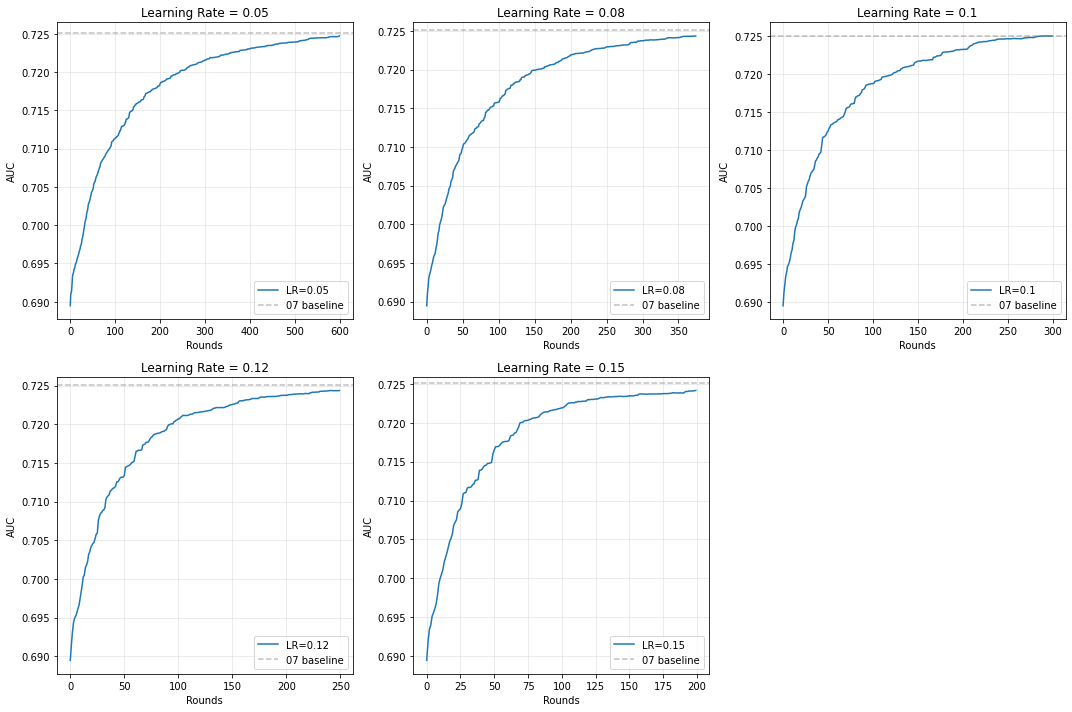


6. Learning rate result comparison...
----------------------------------------------------------------------
LR       AUC      Recall_0   Recall_1   F1_0     F1_1     F1_avg  
----------------------------------------------------------------------
0.05     0.7247   0.696      0.629      0.603    0.694    0.648   
0.08     0.7244   0.694      0.631      0.602    0.695    0.649   
0.10     0.7251   0.694      0.631      0.603    0.695    0.649   
0.12     0.7244   0.694      0.629      0.602    0.693    0.647   
0.15     0.7241   0.694      0.628      0.601    0.693    0.647   
----------------------------------------------------------------------
Best learning rate: 0.1 (AUC=0.7251)

7. Use the best model (LR=0.1) for threshold optimization analysis...

Performance under different thresholds:
----------------------------------------------------------------------
Threshold Recall class 0 Recall class 1 gap      F1_avg  
--------------------------------------------------------------------

In [1]:
# 08_xgboost_test_4.ipynb
# Experiment: Feature selection + learning rate tuning

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("08_xgboost_test_4: Feature selection + learning rate tuning") 
print("="*60)

# 1. Load data
print("\n1. Load data...") 
train = pd.read_csv('../data/train.csv')
print(f"Train shape: {train.shape}") 

# 2. Feature engineering function (keep only useful engineered features)
def create_selected_features(df):
    """Create new features that have proven useful""" 
    df_new = df.copy()
    
    print("\nCreate selected engineered features:") 
    
    # Keep the 3 most useful engineered features(from Experiment 07)
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    print(" ✓ age_family_history created (importance: 0.3596)") 
    
    df_new['age_bmi'] = df['age'] * df['bmi']
    print(" ✓ age_bmi created (importance: 0.0491)") 
    
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    print(" ✓ cardio_risk_score created (importance: 0.0111)") 
    
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    print(" ✓ Cholesterol metrics created") 
    
    print(f"\nCreated a total of {len(df_new.columns) - len(df.columns)} new features") 
    return df_new

# 3. Prepare data
print("\n2. Prepare data...") 
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

X_fe = create_selected_features(X)

# 4. Feature selection: remove replaced original features
print("\n3. Feature selection...") 
print(f"Original feature count: {X_fe.shape[1]}") 

features_to_keep = [
    'age_family_history',
    'age_bmi',
    'cardio_risk_score',
    'cholesterol_ratio',
    'non_hdl_cholesterol',
    
    'physical_activity_minutes_per_week',
    'triglycerides',
    'bmi',
    'ldl_cholesterol',
    'cardiovascular_history',
    'diet_score',
    'heart_rate',
    'systolic_bp',
    'diastolic_bp',
    'hdl_cholesterol',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'alcohol_consumption_per_week',
    'hypertension_history',
    
    'gender', 'ethnicity', 'education_level', 
    'income_level', 'smoking_status', 'employment_status'
]

X_selected = X_fe[features_to_keep]
print(f"Selected feature count: {X_selected.shape[1]}") 
print(f"Removed features: age, family_history_diabetes") 

# 5. Encode categorical features
print("\n4. Encode categorical features...") 
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']

X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"Total encoded feature count: {X_encoded.shape[1]}") 

# 6. Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}") 

# 7. Compute weights
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# 8. Previous experiment results(06)
prev_exp = {
    'name': '07_xgboost_test_3',
    'auc': 0.7251,
    'recall_0': 0.696,
    'recall_1': 0.629,
    'threshold': 0.45
}

print(f"\nBest results from Experiment 07:") 
print(f"- AUC: {prev_exp['auc']}")
print(f"- Recall class 0: {prev_exp['recall_0']}") 
print(f"- Recall class 1: {prev_exp['recall_1']}") 

# 9. Try different learning rates
print("\n5. Try different learning rates...") 

learning_rates = [0.05, 0.08, 0.1, 0.12, 0.15]
n_estimators_map = {
    0.05: 600,
    0.08: 375,
    0.1: 300,
    0.12: 250,
    0.15: 200
}

results_dict = {}
best_auc = 0
best_lr = 0.1
best_model = None

plt.figure(figsize=(15, 10))

for idx, lr in enumerate(learning_rates):
    n_est = n_estimators_map[lr]
    print(f"\n▶ Train learning_rate={lr}, n_estimators={n_est}...") 
    
    model = xgb.XGBClassifier(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        use_label_encoder=False
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Evaluation
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)
    
    auc = roc_auc_score(y_val, y_pred_proba)
    recall_0 = recall_score(y_val, y_pred, pos_label=0)
    recall_1 = recall_score(y_val, y_pred, pos_label=1)
    f1_0 = f1_score(y_val, y_pred, pos_label=0)
    f1_1 = f1_score(y_val, y_pred, pos_label=1)
    
    results_dict[lr] = {
        'model': model,
        'auc': auc,
        'recall_0': recall_0,
        'recall_1': recall_1,
        'f1_0': f1_0,
        'f1_1': f1_1,
        'results': model.evals_result()
    }
    
    print(f" AUC: {auc:.4f} | Recall class 0: {recall_0:.3f} | Recall class 1: {recall_1:.3f} | Mean F1: {(f1_0+f1_1)/2:.3f}") 
    
    if auc > best_auc:
        best_auc = auc
        best_lr = lr
        best_model = model
    
    plt.subplot(2, 3, idx+1)
    results = model.evals_result()
    plt.plot(results['validation_0']['auc'], label=f'LR={lr}')
    plt.axhline(y=prev_exp['auc'], color='gray', linestyle='--', alpha=0.5, label=f'07 baseline')
    plt.xlabel('Rounds')
    plt.ylabel('AUC')
    plt.title(f'Learning Rate = {lr}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/08_xgboost_test_4_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# 10. Results comparison
print("\n6. Learning rate result comparison...") 
print("-" * 70)
print(f"{'LR':<8} {'AUC':<8} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<8} {'F1_1':<8} {'F1_avg':<8}")
print("-" * 70)

for lr in learning_rates:
    r = results_dict[lr]
    f1_avg = (r['f1_0'] + r['f1_1']) / 2
    print(f"{lr:<8.2f} {r['auc']:<8.4f} {r['recall_0']:<10.3f} {r['recall_1']:<10.3f} {r['f1_0']:<8.3f} {r['f1_1']:<8.3f} {f1_avg:<8.3f}")

print("-" * 70)
print(f"Best learning rate: {best_lr} (AUC={best_auc:.4f})") 

# 11. Run threshold analysis with the best model
print(f"\n7. Use the best model (LR={best_lr}) for threshold optimization analysis...") 

y_pred_proba_best = best_model.predict_proba(X_val)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
best_f1_avg = 0
best_threshold = 0.45

print("\nPerformance under different thresholds:") 
print("-" * 70)
print(f"{'Threshold':<8} {'Recall class 0':<10} {'Recall class 1':<10} {'gap':<8} {'F1_avg':<8}") 
print("-" * 70)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(float)
    r0 = recall_score(y_val, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val, y_pred_thresh, pos_label=1)
    f1_avg = (f1_0 + f1_1) / 2
    gap = r1 - r0
    print(f"{thresh:<8.2f} {r0:<10.3f} {r1:<10.3f} {gap:<8.3f} {f1_avg:<8.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 70)
print(f"Best threshold: {best_threshold} (Mean F1={best_f1_avg:.3f})") 

# 12. Feature importance analysis(using the best model)
print("\n8. Feature importance analysis...") 

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:") 
print(importance.head(15).to_string(index=False))

# 13. Save model and submission file
print("\n9. Save model and submission file...") 

model_path = f'../models/08_xgboost_test_4_lr{best_lr}.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}") 

test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_fe = create_selected_features(X_test)
X_test_selected = X_test_fe[features_to_keep]
X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)

missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

test_pred = best_model.predict_proba(X_test_encoded)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission_path = '../submissions/08_xgboost_test_4.csv'
submission.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}")


# Experiment 8 Summary: Feature Selection and Learning-Rate Tuning

## Role in the series
This stage combines feature-space refinement with a focused learning-rate study. It represents the strongest point of the holdout-validation XGBoost track before the methodology later moves toward more reliable cross-validation.

## Interpretation
The notebook is important because it shows how far the original holdout pipeline could be pushed. At the same time, it highlights the need for the stronger validation redesign that appears in Notebook 11 and the later supporting analyses.

## Consistency note
The experiment labels, saved paths, and notebook numbering now use the same `08_xgboost_test_4` naming so that the notebook and its artifacts stay aligned.
